# Análisis Exploratorio de Datos (Práctica)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('bank-full.csv', sep=';')

In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

Primeras filas del DataFrame:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


Ultimas filas del DataFrame:
       age           job   marital  education default  balance housing loan  \
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome    y  
45206   cellular   17   nov       977         3     -1         0  unknown  yes  
45207   cellular   17   nov       456         2     -1         0  unknown  yes  
45208   cellular   17   nov      1127         5    184         3  success  yes  
45209  telephone   17   nov       508         4     -1         0  unknown   no  
45210   cellular   17   nov       361         2    188        11    other   no  
Informacio

**Variables numericas**

In [4]:
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

**Visualizar distribuciones**

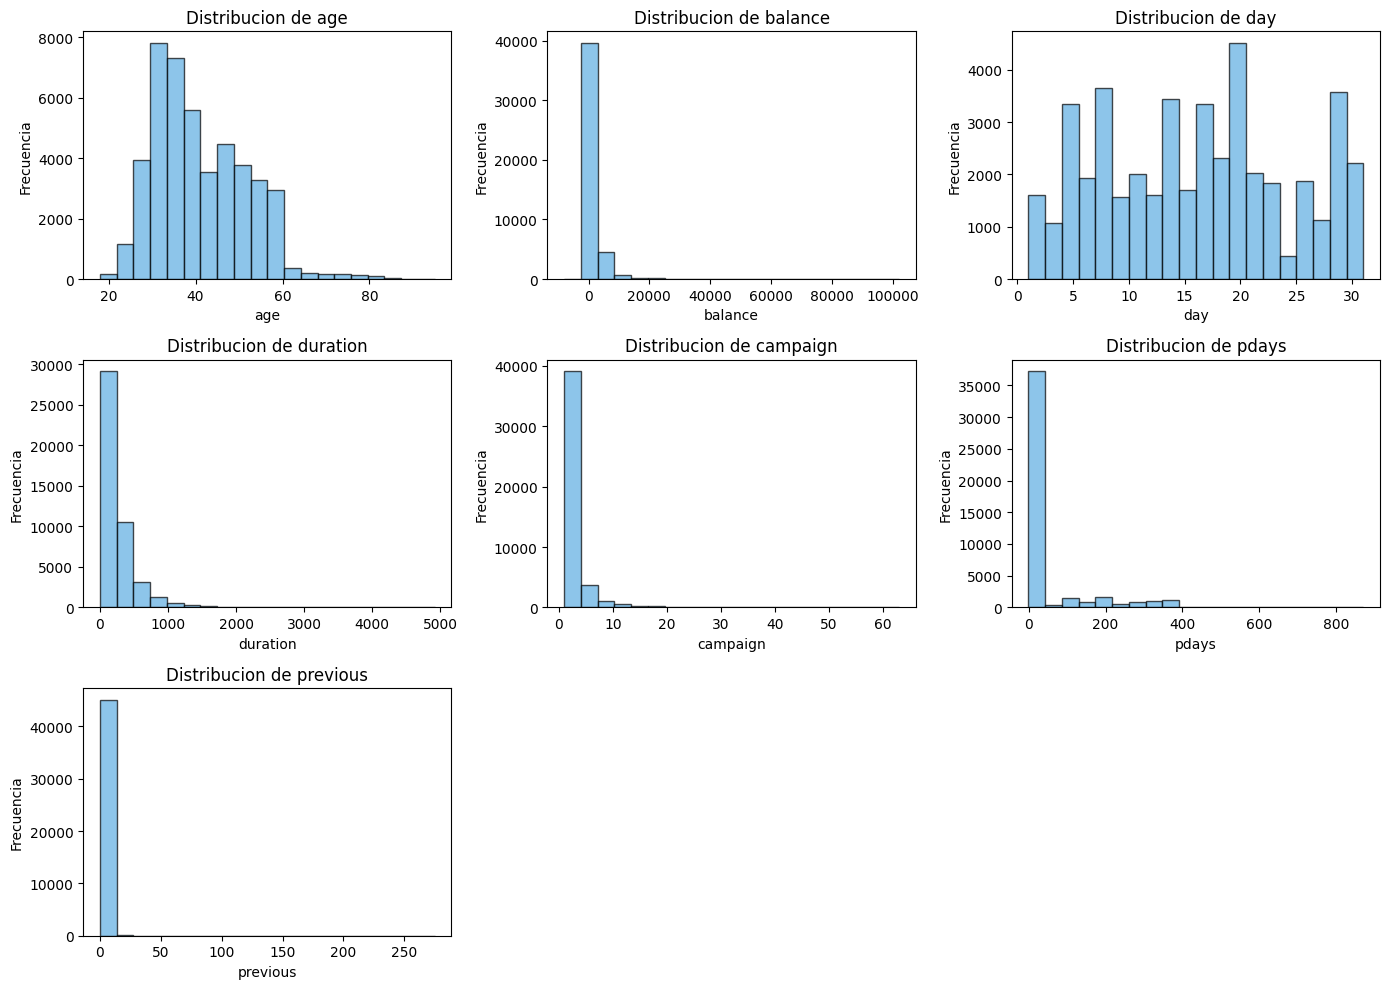

In [5]:
plt.figure(figsize=(14,10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,3,i)
    plt.hist(df[col], bins=20, color='#5DADE2', edgecolor='black', alpha=0.7)
    plt.title(f'Distribucion de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Analizar correlaciones**

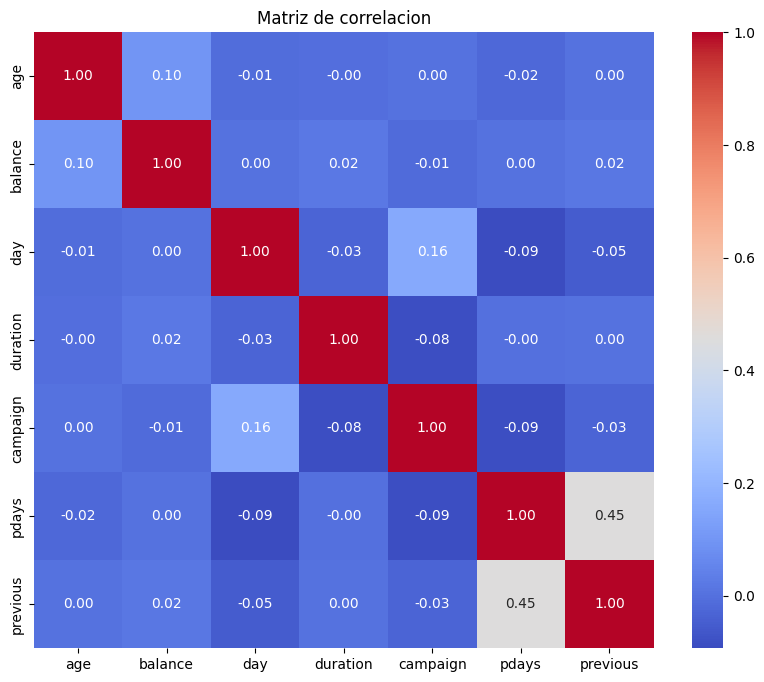

In [7]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion')
plt.show()

**Identificar valores atipicos**

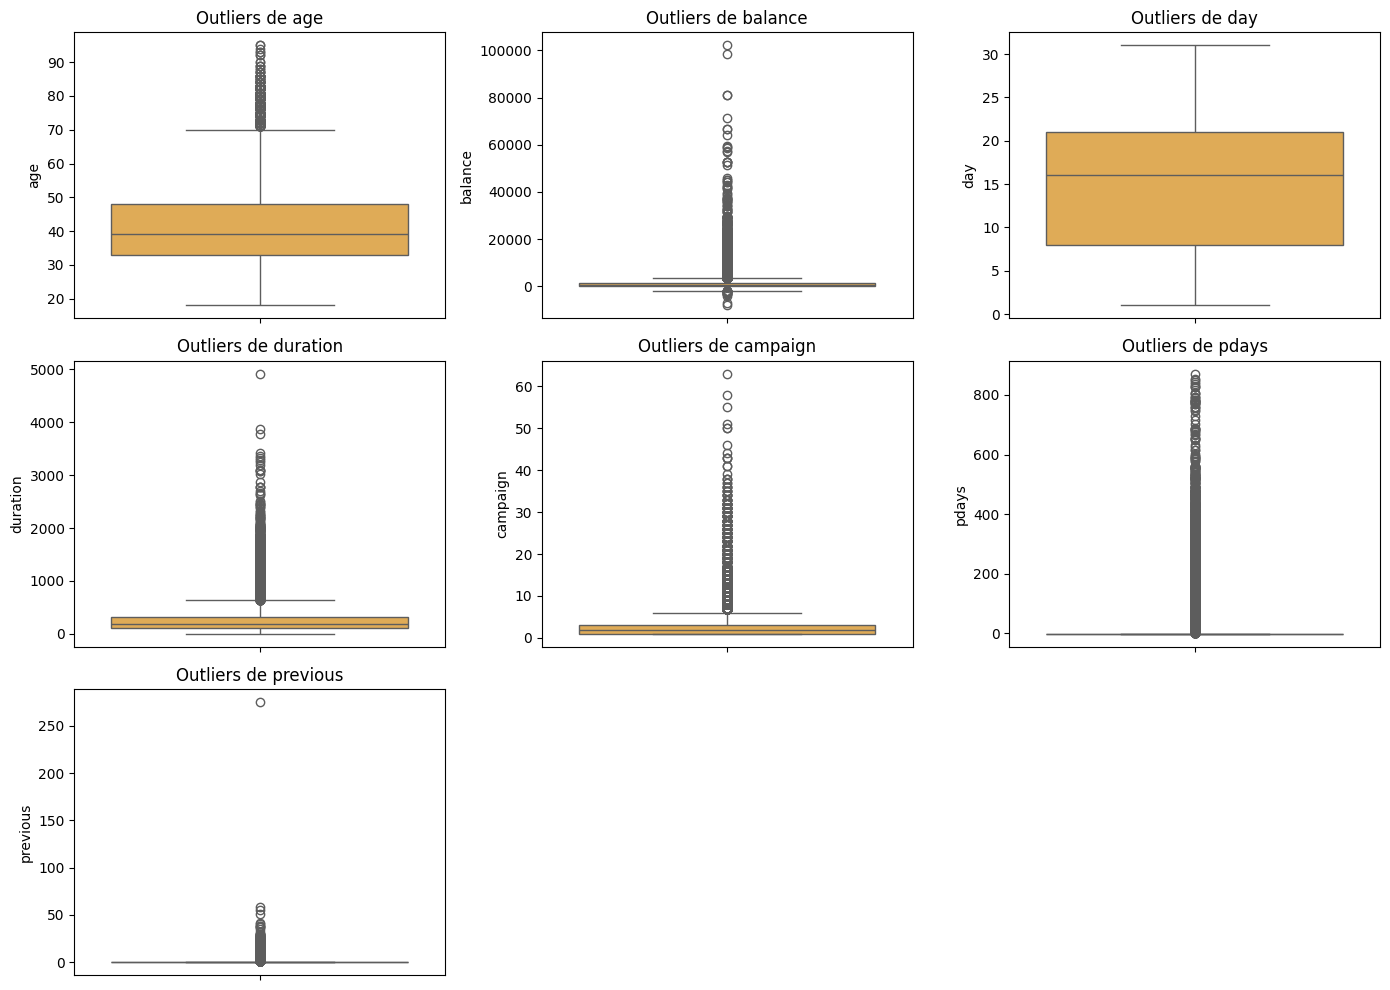

In [8]:
plt.figure(figsize=(14,10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col], color='#F5B041')
    plt.title(f'Outliers de {col}')

plt.tight_layout()
plt.show()


**Deteccion de outliers con IQR**

In [9]:
def detectar_outliers(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return len(outliers)

print('\nCantidad de outliers por variable:\n')

for col in numerical_cols:
    cantidad = detectar_outliers(df, col)
    print(f'{col}: {cantidad} outliers')


Cantidad de outliers por variable:

age: 487 outliers
balance: 4729 outliers
day: 0 outliers
duration: 3235 outliers
campaign: 3064 outliers
pdays: 8257 outliers
previous: 8257 outliers


In [11]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_sin_outliers = df[(df['balance'] >= limite_inferior) & (df['balance'] <= limite_superior)]

print('\nTamaño original del dataset:')
print(df.shape)

print('\nTamaño sin outliers en balance:')
print(df_sin_outliers.shape)


Tamaño original del dataset:
(45211, 17)

Tamaño sin outliers en balance:
(40482, 17)
